In [ ]:
#Run those codes in shell
# The raw data were PRJNA634693. 1792_fl_con-multi for DMSO group and 1792_fl_mod_75/100/150-multi for Aclm group.
#1、the raw fastq were basecalled using guppy V 3.1.5. combine reads and run DeCoRE.
cat 1792_fl_con-multi/*.fastq >>1792_fl_con-multi/all.fastq;
sed "s/U/T/g' 1792_fl_con-multi/all.fastq > Unmod/all.T.fastq;

ref=/data1/huangyong/Project/Nanopore/nanoSHAPE/miR17-92a.fa
outdir=/data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod
Mod_fast5=/data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_mod_150-multi/workspace #change to 1792_fl_mod_100/75 and run DecoRE again
Unmod_fast5=/data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/workspace
dir_=/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Mod150/all.T.fastq  -s $Mod_fast5 -S $Mod_fast5/sequencing_summary.txt -d $dir_ -n Mod150 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Unmod/all.T.fastq  -s $Unmod_fast5 -S $Unmod_fast5/sequencing_summary.txt -d $dir_ -n Unmod -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m $dir_/Mod150.collapsed.event -u $dir_/Unmod.collapsed.event -l 950 -b 1  # l+b=951
python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m $dir_/Mod150.collapsed.event.profile.vect -u $dir_/Unmod.collapsed.event.profile.vect -o Mod150_scores -s mean 

#2 compare with other 3 methods
# PORE_cupine
srun  --nodelist node526 Rscript Read_events_raw.R -f Unmod/Unmod.event -o Unmod/Unmod.collapse.event.Rdata
srun  --nodelist node525 Rscript Read_events_raw.R -f Mod150/Mod150.event -o Mod150/Mod150.collapse.event.Rdata
srun  --nodelist node525 Rscript SVM.R -m Mod150/Mod150.collapse.event.Rdata -u Unmod/Unmod.collapse.event.Rdata -l 951 -o Mod150/PrimR_PORE_cupine.csv

#nanoSHAPE run in python
Prim_Unmodevent=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/Unmod.collapse.event',sep='\t',index_col=0)
Prim_Modevent=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Mod150.collapse.event',sep='\t',index_col=0)
posList_prim=[i for i in range(1,952)]
from scipy.stats import ks_2samp
from statsmodels.stats.multitest import multipletests
Prim_nanoshape=[]
for b in posList_prim:
    Train=Prim_Unmodevent[Prim_Unmodevent['position']==b]
    Test=Prim_Modevent[Prim_Modevent['position']==b]
    if Test.shape[0] >10 and Train.shape[0] >10:
        S,P=ks_2samp(Test.iloc[:,4],Train.iloc[:,4],mode="asymp")
        Prim_nanoshape.append([P,b,Test.shape[0],Train.shape[0]])
    else:
        Prim_nanoshape.append([0,b,Test.shape[0],Train.shape[0]])
Prim_nanoshape_disc=pd.DataFrame(Prim_nanoshape,columns=['Modifired_rate','Position','Test_NO.','Train_NO.'])
P_correlate=multipletests(Prim_nanoshape_disc['Modifired_rate'].tolist(),method='fdr_bh')
P_list=[-math.log10(i) if i >0 else 0 for i in P_correlate[1].tolist()]
Prim_nanoshape_disc.to_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Prim_nanoshape.csv',sep='\t',index=False)
PrimnanoSHAPEscores=Normal_SHAPE(P_list,windowsize=200)
nanoshapedf=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Prim_nanoshape.csv',sep='\t')
nanoSHAPEscores=Normal_SHAPE(nanoshapedf['Modifired_NO.'].tolist(),windowsize=200)

#nanoCompore
nanocompore eventalign_collapse -i Unmod/Unmod.sample.event -o Mod150/nanocompore/Unmod.tsv &
nanocompore eventalign_collapse -i Mod150/Mod150.event -o Mod150/nanocompore/Mod150.tsv
nanocompore sampcomp --nthreads 20 -1 Mod150/nanocompore/Unmod.tsv/out_eventalign_collapse.tsv  -2  Mod150/nanocompore/Mod150.tsv/out_eventalign_collapse.tsv -f miR17-92a.fa -o Mod150/nanocompore --overwrite


#3、Basecall reads using guppy V6.5.7 and dorado. combine reads and run DeCoRE.
#2026.3.18使用新的guppy（V6.5.7）模型对priM27~91RNA 的数据重新basecalling
srun  --nodelist node525 /data1/huangyong/soft/ont-guppy-cpu/bin/guppy_basecaller -i /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/workspace -s /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall -c /data1/huangyong/soft/ont-guppy-cpu/data/rna_r9.4.1_70bps_hac.cfg -r  --num_callers 16 --cpu_threads_per_caller 16;
/data1/huangyong/soft/ont-guppy-cpu/bin/guppy_basecaller -i /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_mod_150-multi/workspace -s /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall -c /data1/huangyong/soft/ont-guppy-cpu/data/rna_r9.4.1_70bps_hac.cfg -r  --num_callers 16 --cpu_threads_per_caller 16;

cat /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall/pass/*.fastq >> /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/Guppy6.fastq
cat /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall/pass/*.fastq >> /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Guppy6.fastq
sed -s 's/U/T/g' /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall/Guppy6.fastq >/data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall/Guppy6.T.fastq
sed -s 's/U/T/g' /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall/Guppy6.fastq >/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall/Guppy6.T.fastq
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r /data1/huangyong/Project/Nanopore/nanoSHAPE/miR17-92a.fa -q /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall/Guppy6.T.fastq -s /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/workspace -S /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/sequencing_summary.txt -d /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall -n Guppy6 -t 10
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r /data1/huangyong/Project/Nanopore/nanoSHAPE/miR17-92a.fa -q /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall/Guppy6.T.fastq -s /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_mod_150-multi/workspace -S /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_mod_150-multi/sequencing_summary.txt -d /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall -n Guppy6 -t 20
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall/Guppy6.filt.event -u /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall/Guppy6.filt.event -l 950 

#2026.3.18使用dorado对priM27~91RNA 的数据重新basecalling
下载model
bin/dorado download --model rna002_70bps_hac@v3 --models-directory model/
运行
bin/dorado basecaller  --trim all --output-dir /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/dorado/  /data1/huangyong/soft/dorado-0.8.2-linux-x64/model/rna002_70bps_hac@v3  /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/workspace/ 
srun /data1/huangyong/soft/dorado-0.8.2-linux-x64/bin/dorado basecaller  --trim all --output-dir /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/dorado/  /data1/huangyong/soft/dorado-0.8.2-linux-x64/model/rna002_70bps_hac@v3  /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_mod_150-multi/workspace/ &
samtools fastq calls_2026-03-19_T01-39-32.bam >dorado.fastq
nanopolish index -d /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/workspace -s /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/sequencing_summary.txt /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/dorado/dorado.fastq
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r /data1/huangyong/Project/Nanopore/nanoSHAPE/miR17-92a.fa -q /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/dorado/dorado.fastq -s /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/workspace -S /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_con-multi/sequencing_summary.txt -d /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/dorado -n dorado -t 20 &
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r /data1/huangyong/Project/Nanopore/nanoSHAPE/miR17-92a.fa -q /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/dorado/dorado.fastq -s /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_mod_150-multi/workspace -S /data1/huangyong/Project/Nanopore/nanoSHAPE/1792_fl_mod_150-multi/sequencing_summary.txt -d /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/dorado -n dorado -t 20 &
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m /data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/dorado/dorado.filt_l.event -u /data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/dorado/dorado.filt_l.event -l 950 


In [2]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None
from RNA import General,Structure, Visual
from scipy import stats
from statistics import mean
import math
from scipy.stats import spearmanr
from scipy.stats import pearsonr


In [3]:
def CalculateSHAPEFromBitvector_mod(Modvect):
    Percentlist=[]
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    rates=NAI_one/(NAI_one+NAI_zero)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def CalculateSHAPEFromBitvector_control(Modvect,Unmodvect,alpha=1):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero)+np.multiply(delta,alpha)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def Normal_SHAPE(inlist,windowsize=200,step=5): #采用icSHAPE-pipe的策略，在Windows内，top5%为1，最低5%为0
    shape=[[] for i in range(len(inlist))]
    finalshape=[0 for i in range(len(inlist))]
    start=0
    while start+windowsize< len(inlist):
        sublist=np.array(inlist[start:start+windowsize])
        s95=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 95)
        s5=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 5)
        subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in sublist]
        for i in range(windowsize):
            shape[start+i].append(subshape[i])
        start+=step
    #处理最后一个window
    endsublist=np.array(inlist[start:])
    s95=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 95)
    s5=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 5)
    subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in endsublist]
    for i in range(len(endsublist)):
        shape[start+i].append(subshape[i])
    #对每个位置的值求平均
    for i in range(len(inlist)):
        finalshape[i]=mean(shape[i])
    return finalshape
    
def get_index(lst=None, item=''):
    return [index for (index,value) in enumerate(lst) if value == item]


def color_SHAPE(shape_list, cutoff=[0.3, 0.5, 0.7]):
    """
    shape_list              -- A list of SHAPE scores
    cutoff                  -- Cutoff of SHAPE color boundaries.
    
    Transform SHAPE values to color blocks
    """
    color_blocks=[]
    for value in shape_list:
        if value == 'NULL':
            color_blocks.append('lightgray')
        else:
            shape = float(value)
            if shape < cutoff[0]:
                color_blocks.append('black')
            elif shape < cutoff[1]:
                color_blocks.append('blue')
            elif shape < cutoff[2]:
                color_blocks.append('orange')
            else:
                color_blocks.append('red')
    
    return color_blocks

def SHAPEWindowcorrelation(shape1,shape2,windowsize):
    my_list1 = [0 if math.isnan(x) else x for x in shape1]
    my_list2 = [0 if math.isnan(x) else x for x in shape2]
    corre=[]
    start=0
    size=windowsize
    while start+size < len(my_list1):
        end=start+size
        subshape1=my_list1[start:end]
        subshape2=my_list2[start:end]
        t, p = scipy.stats.pearsonr(subshape1, subshape2)
        corre.append(round(t, 3))
        start+=1
    head=[0 for i in range(int(windowsize/2))]
    return head+corre+head
def fill_ends(row):
    first_valid_index = int(row.first_valid_index())
    last_valid_index = int(row.last_valid_index())
    row.iloc[:first_valid_index] = 0
    row.iloc[last_valid_index + 1:] = 0
    return row

In [5]:
#导入数据
Bitvector150=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Mod150.event.filt2.profile.vect',sep='\t',index_col=0)#2.9万条
Bitvector75=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/M75/m75.vect',sep='\t',index_col=0).apply(fill_ends, axis=1).fillna(2)#2.9万条
Bitvector100=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/M100/m100.vect',sep='\t',index_col=0).apply(fill_ends, axis=1).fillna(2)#2.9万条
DMSOBitvector=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/Unmod.event.filt2.profile.vect',sep='\t',index_col=0)


In [51]:
BitverGuppyV6=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/basecall/Guppy6.filt_l.event.profile.vect',sep='\t',index_col=0)#0.8万条
DMSOGuppyV6=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/basecall/Guppy6.filt_l.event.profile.vect',sep='\t',index_col=0)

BitverDorado=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/dorado/dorado.filt_l.event.profile.vect',sep='\t',index_col=0)#0.8万条
DMSODorado=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Unmod/dorado/dorado.filt_l.event.profile.vect',sep='\t',index_col=0)


In [28]:
mirdotfile=General.load_dot('/data1/huangyong/Project/Nanopore/nanoSHAPE/miR17-92a.dot')
mirseq=mirdotfile['miR17-92a'][0]
mirdot=mirdotfile['miR17-92a'][1]
posList_mir=[i for i in range(0,len(mirseq))]

mirdot_6=mirdot[110:180]+mirdot[249:320]+mirdot[392:468]+mirdot[572:624]+mirdot[684:783]+mirdot[821:880]
mirseq_6=mirseq[110:180]+mirseq[249:320]+mirseq[392:468]+mirseq[572:624]+mirseq[684:783]+mirseq[821:880]


2.139690650886796
9.600173478006907
5.552899164688586
0.3645723599618176
0.5335500211436578


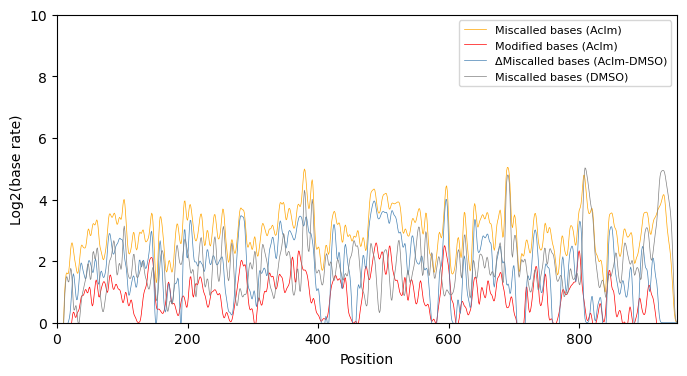

In [31]:
Aclm_one=np.mean(Bitvector150==1,axis=0)*100
Aclm_two=np.mean(Bitvector150==2,axis=0)*100
DMSO=np.mean(DMSOBitvector==2,axis=0)*100

print(np.mean(Aclm_one))
print(np.mean(Aclm_two))
print(np.mean(DMSO))
def Winsor_Normal(inlist): 
    s95=stats.scoreatpercentile(inlist, 99)
    s5=stats.scoreatpercentile(inlist, 1)
    sublist=[s95 if i>s95 else (1 if i<s5 else i) for i in inlist]
    return sublist

Norm_mod=Winsor_Normal(Aclm_one)
Norm_mis=Winsor_Normal(Aclm_two)
Norm_doms_2=Winsor_Normal(DMSO)
Norm_Delta_mis=Winsor_Normal(Aclm_two-DMSO)

Fold_mod=[math.log2(i) if (i>0) else 0 for i in Norm_mod]
Fold_mis=[math.log2(i) if (i>0) else 0 for i in Norm_mis]
Fold_mis_DMSO=[math.log2(i) if (i>0) else 0 for i in Norm_doms_2]
Fold_Delta_mis=[math.log2(i) if (i>0) else 0 for i in Norm_Delta_mis]

'''
Fold_mod=[i if (i>0) else 0 for i in Norm_mod]
Fold_mis=[i if (i>0) else 0 for i in Norm_mis]
Fold_mis_DMSO=[i if (i>0) else 0 for i in Norm_doms_2]
Fold_Delta_mis=[i if (i>0) else 0 for i in Norm_Delta_mis]
'''

R1,P1=pearsonr(Fold_mod,Fold_mis)
R2,P2=pearsonr(Fold_mod, Fold_Delta_mis)
print(R1)
print(R2)


from scipy.ndimage import gaussian_filter1d
Norm_mod_smooth=gaussian_filter1d(Fold_mod, sigma=2)
Norm_mis_smooth=gaussian_filter1d(Fold_mis, sigma=2)
Norm_mis_smooth_DMSO=gaussian_filter1d(Fold_mis_DMSO, sigma=2)
Norm_Delta_mis_smooth=gaussian_filter1d(Fold_Delta_mis, sigma=2)


pos=[i for i in range(0,951)]
plt.close()
plt.figure(figsize=(8,4))
plt.style.use('default')  # 使用默认样式
plt.plot(pos,Norm_mis_smooth,'Orange', linewidth=0.5,label='Miscalled bases (Aclm)')
plt.plot(pos,Norm_mod_smooth,'red', linewidth=0.5,label='Modified bases (Aclm)')
plt.plot(pos,Norm_Delta_mis_smooth,'SteelBlue', linewidth=0.5,label='ΔMiscalled bases (Aclm-DMSO)')
plt.plot(pos,Norm_mis_smooth_DMSO,'gray', linewidth=0.5,label='Miscalled bases (DMSO)')

plt.legend(fontsize=8)
plt.xlim(0,950)
plt.ylim(0,10)
plt.xlabel('Position',fontsize=10)
plt.ylabel('Log2(base rate)',fontsize=10)

#plt.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Modify and miscall rate correlation per postion4.2.pdf")
#plt.close()
plt.show()

In [37]:
NAIone=np.sum(Bitvector150==1,axis=0)
NAIone_mean=Winsor_Normal(NAIone/len(Bitvector150)*100)
Aclm_one=np.mean(Bitvector150==1,axis=0)*100
print(pearsonr(NAIone_mean,Winsor_Normal(Aclm_one)))

PearsonRResult(statistic=0.9999999999999996, pvalue=0.0)


0.6192757364380489
0.5866037412960922


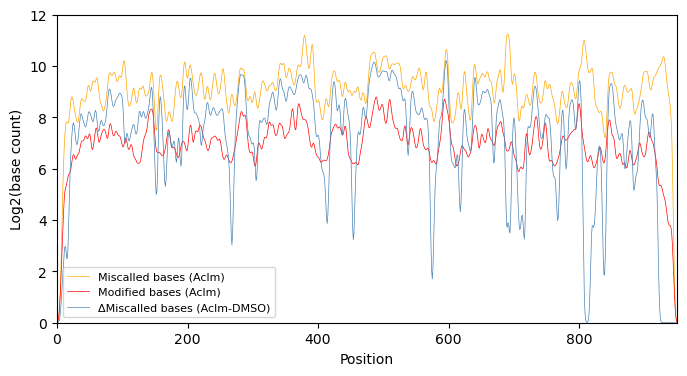

In [73]:

NAIone=np.sum(Bitvector150==1,axis=0)
NAItwo=np.sum(Bitvector150==2,axis=0)
Aclm_2=np.sum(DMSOBitvector==2,axis=0)
'''
NAIone=np.mean(Bitvector150==1,axis=0)*100
NAItwo=np.mean(Bitvector150==2,axis=0)*100
Aclm_2=np.mean(DMSOBitvector==2,axis=0)*100
'''
def Winsor_Normal(inlist): 
    s95=stats.scoreatpercentile(inlist, 99)
    s5=stats.scoreatpercentile(inlist, 1)
    sublist=[s95 if i>s95 else (1 if i<s5 else i) for i in inlist]
    return sublist


Norm_mod=Winsor_Normal(NAIone)
Norm_mis=Winsor_Normal(NAItwo)
Norm_Aclm_2=Winsor_Normal(Aclm_2)
Norm_Delta_mis=Winsor_Normal(NAItwo-Aclm_2*len(Bitvector150)/len(DMSOBitvector))
'''
Fold_mod=[i if (i>0) else 0 for i in Norm_mod]
Fold_mis=[i if (i>0) else 0 for i in Norm_mis]
Fold_mis_DMSO=[i if (i>0) else 0 for i in Norm_Aclm_2]
Fold_Delta_mis=[i if (i>0) else 0 for i in Norm_Delta_mis]
'''
Fold_mod=[math.log2(i) if (i>0) else 0 for i in Norm_mod]
Fold_mis=[math.log2(i) if (i>0) else 0 for i in Norm_mis]
Fold_mis_DMSO=[math.log2(i) if (i>0) else 0 for i in Norm_Aclm_2]
Fold_Delta_mis=[math.log2(i) if (i>0) else 0 for i in Norm_Delta_mis]


R1,P1=pearsonr(Fold_mod,Fold_mis)
R2,P2=pearsonr(Fold_mod, Fold_Delta_mis)
#R3,P3=pearsonr(Fold_mod/len(Bitvector150), Fold_mis/len(Bitvector150))
print(R1)
print(R2)
#print(R3)


from scipy.ndimage import gaussian_filter1d
Norm_mod_smooth=gaussian_filter1d(Fold_mod, sigma=2)
Norm_mis_smooth=gaussian_filter1d(Fold_mis, sigma=2)
Norm_mis_smooth_DMSO=gaussian_filter1d(Fold_mis_DMSO, sigma=2)
Norm_Delta_mis_smooth=gaussian_filter1d(Fold_Delta_mis, sigma=2)


pos=[i for i in range(0,951)]
plt.close()
plt.figure(figsize=(8,4))
plt.style.use('default')  # 使用默认样式
plt.plot(pos,Norm_mis_smooth,'Orange', linewidth=0.5,label='Miscalled bases (Aclm)')
plt.plot(pos,Norm_mod_smooth,'red', linewidth=0.5,label='Modified bases (Aclm)')
#plt.plot(pos,Norm_mis_smooth_DMSO,'gray', linewidth=0.5,label='DMSO Miscalled bases')
plt.plot(pos,Norm_Delta_mis_smooth,'SteelBlue', linewidth=0.5,label='ΔMiscalled bases (Aclm-DMSO)')

plt.legend(fontsize=8)
plt.xlim(0,950)
plt.ylim(0,12)
plt.xlabel('Position',fontsize=10)
plt.ylabel('Log2(base count)',fontsize=10)

plt.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Modify and miscall correlation per postion3.24.pdf")
#plt.close()
plt.show()

In [44]:
NAI_vect=Bitvector150  #修改后画其它两个
DMSO_vect=DMSOBitvector
NAI_one=np.sum(NAI_vect==1,axis=0)
NAI_zero=np.sum(NAI_vect==0,axis=0)
NAI_two=np.sum(NAI_vect==2,axis=0)
DMSO_two=np.sum(DMSO_vect==2,axis=0)
DMSO_zero=np.sum(DMSO_vect==0,axis=0)

Rtemp=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
R=NAI_one/(NAI_one+NAI_zero)+Rtemp

Prim_scores_DMSO=Normal_SHAPE(DMSO_two/(DMSO_two+DMSO_zero),windowsize=200)
Prim_scores_mis=Normal_SHAPE(NAI_two/(NAI_two+NAI_zero+NAI_one),windowsize=200)
Prim_scores_mod=Normal_SHAPE(NAI_one/(NAI_one+NAI_zero),windowsize=200)
Prim_scores_mis_mod=Normal_SHAPE(Rtemp,windowsize=200)
Prim_scores_DecoRe=Normal_SHAPE(R,windowsize=200)


In [45]:
Start=2
scores=Prim_scores_DMSO
DMSO_scores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
DMSO_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,DMSO_scores_6))
print(f"DMSO, AUC:{DMSO_auc}")

scores=Prim_scores_mis
mis_scores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
mis_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,mis_scores_6))
print(f"Mis, AUC:{mis_auc}")

scores=Prim_scores_mod
mod_scores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
mod_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,mod_scores_6))
print(f"Mod, AUC:{mod_auc}")

scores=Prim_scores_mis_mod
mis_mod_scores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
mis_mod_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,mis_mod_scores_6))
print(f"Mis_mod, AUC:{mis_mod_auc}")

scores=Prim_scores_DecoRe
DecoRe_scores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
DecoRe_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,DecoRe_scores_6))
print(f"DecoRe, AUC:{DecoRe_auc}")

DMSO, AUC:0.421
Mis, AUC:0.706
Mod, AUC:0.795
Mis_mod, AUC:0.779
DecoRe, AUC:0.820


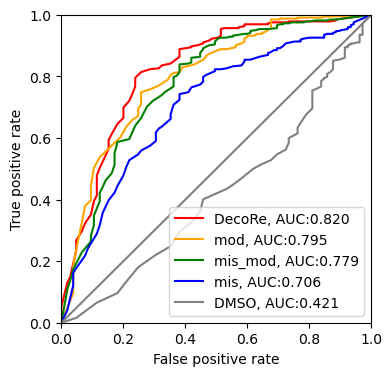

In [48]:
ROC_DMSO=General.calc_shape_structure_ROC(mirdot_6,DMSO_scores_6, start=0.0, step=0.01, stop=1.0)
ROC_mis=General.calc_shape_structure_ROC(mirdot_6,mis_scores_6, start=0.0, step=0.01, stop=1.0)
ROC_mod=General.calc_shape_structure_ROC(mirdot_6,mod_scores_6, start=0.0, step=0.01, stop=1.0)
ROC_mis_mod=General.calc_shape_structure_ROC(mirdot_6,mis_mod_scores_6, start=0.0, step=0.01, stop=1.0)
ROC_DecoRe=General.calc_shape_structure_ROC(mirdot_6,DecoRe_scores_6, start=0.0, step=0.01, stop=1.0)

fig = plt.figure(1, figsize=(4, 4))
ax = fig.add_subplot(111)
#x = [ i[0] for i in ROC ]
#y = [ i[1] for i in ROC ]
ax.plot([i[0] for i in ROC_DecoRe ],[i[1] for i in ROC_DecoRe ], '-', color='red',label=f'DecoRe, AUC:{DecoRe_auc}')
ax.plot([i[0] for i in ROC_mod ],[i[1] for i in ROC_mod ], '-', color='orange',label=f'mod, AUC:{mod_auc}')
ax.plot([i[0] for i in ROC_mis_mod ],[i[1] for i in ROC_mis_mod ], '-', color='green',label=f'mis_mod, AUC:{mis_mod_auc}')
ax.plot([i[0] for i in ROC_mis ],[i[1] for i in ROC_mis ], '-', color='blue',label=f'mis, AUC:{mis_auc}')
ax.plot([i[0] for i in ROC_DMSO ],[i[1] for i in ROC_DMSO ], '-', color='gray',label=f'DMSO, AUC:{DMSO_auc}')

ax.plot([0,1], [0,1], '-', color='gray')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
#ax.title("AUC-ROC on pri-miR-17~92 RNA")
ax.legend()
#fig.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/5_Straitagy_ROC_Dorado.pdf") #修改后画其它两个
#plt.close()
plt.show()

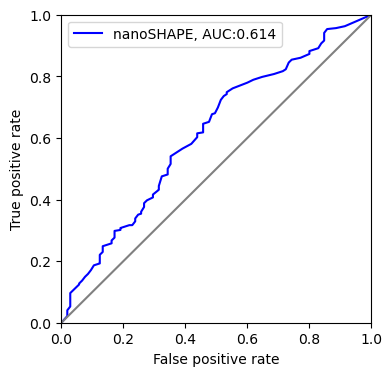

In [49]:
loadData = np.load('/data2/zhome/huangyong/Jupyter/rRNA_nanoSHAPE-master/nanomod_data/1792_mod150_flen_prstats.npy',allow_pickle=True,encoding="latin1")
data_df= pd.DataFrame(loadData)
grouped = data_df.groupby(by=['pos']).agg({'stat':'mean','read_id':'first'})
PrimnanoSHAPEscores=Normal_SHAPE(grouped['stat'].tolist(),windowsize=100)
Start=-11+2
scores=PrimnanoSHAPEscores
Prim_nanoSHAPEscores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
General.calc_AUC_v2(mirdot_6,Prim_nanoSHAPEscores_6)
ROC1=General.calc_shape_structure_ROC(mirdot_6, Prim_nanoSHAPEscores_6, start=0.0, step=0.01, stop=1.0)

fig = plt.figure(1, figsize=(4, 4))
ax = fig.add_subplot(111)
#x = [ i[0] for i in ROC ]
#y = [ i[1] for i in ROC ]
ax.plot([i[0] for i in ROC1 ],[i[1] for i in ROC1 ], '-', color='blue',label='nanoSHAPE, AUC:0.614')

ax.plot([0,1], [0,1], '-', color='gray')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
#fig.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/4Methods_ROC_nanoSHAPE.pdf")
#plt.close()
plt.show()

0.772 0.614 0.623 0.820


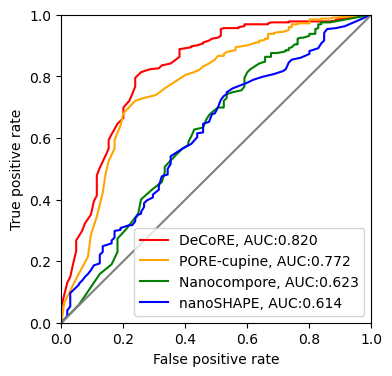

In [51]:
#Compare with other methods
Start=2
Prim_PORE_cupine=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/PrimR_PORE_cupine.csv',sep=',',index_col=0)
Prim_PORE_cupine_scores=Normal_SHAPE(Prim_PORE_cupine['Mod_percentage'],windowsize=200)
scores=Prim_PORE_cupine_scores
Prim_PORE_cupinescores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
PORE_cupine_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,Prim_PORE_cupinescores_6))
PORE_cupine_ROC=General.calc_shape_structure_ROC(mirdot_6,Prim_PORE_cupinescores_6, start=0.0, step=0.01, stop=1.0)

loadData = np.load('/data2/zhome/huangyong/Jupyter/rRNA_nanoSHAPE-master/nanomod_data/1792_mod150_flen_prstats.npy',allow_pickle=True,encoding="latin1")
data_df= pd.DataFrame(loadData)
Start=-11+2
grouped = data_df.groupby(by=['pos']).agg({'stat':'mean','read_id':'first'})
nanoSHAPEscores=Normal_SHAPE(grouped['stat'].tolist(),windowsize=100)
#nanoshapedf=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/Prim_nanoshape.csv',sep='\t')
#nanoSHAPEscores=Normal_SHAPE(nanoshapedf['Modifired_NO.'].tolist(),windowsize=200)
scores=nanoSHAPEscores
nanoSHAPEscores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
nanoSHAPE_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,nanoSHAPEscores_6))
nanoSHAPE_ROC=General.calc_shape_structure_ROC(mirdot_6,nanoSHAPEscores_6, start=0.0, step=0.01, stop=1.0)

Start=2
nanoCompore=pd.read_csv('/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/nanocompore/outnanocompore_results.tsv',sep='\t',index_col=0)
Prim_mod=-np.log(nanoCompore['GMM_logit_pvalue'])
nanoComporescores=Normal_SHAPE(Prim_mod,windowsize=200)
nanoComporescores=[0,0,0,0,0,0,0]+nanoComporescores
scores=nanoComporescores
nanoComporescores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
new_a = np.nan_to_num(nanoComporescores_6, nan=0)
nanoCompore_auc="{:.3f}".format(General.calc_AUC_v2(mirdot_6,new_a))
nanoCompore_ROC=General.calc_shape_structure_ROC(mirdot_6,new_a, start=0.0, step=0.01, stop=1.0)

print(PORE_cupine_auc,nanoSHAPE_auc,nanoCompore_auc,DecoRe_auc)

fig = plt.figure(1, figsize=(4, 4))
ax = fig.add_subplot(111)
ax.plot([i[0] for i in ROC_DecoRe ],[i[1] for i in ROC_DecoRe ], '-', color='red',label=f'DeCoRE, AUC:{DecoRe_auc}')
ax.plot([i[0] for i in PORE_cupine_ROC ],[i[1] for i in PORE_cupine_ROC ], '-', color='orange',label=f'PORE-cupine, AUC:{PORE_cupine_auc}')
ax.plot([i[0] for i in nanoCompore_ROC ],[i[1] for i in nanoCompore_ROC ], '-', color='green',label=f'Nanocompore, AUC:{nanoCompore_auc}')
ax.plot([i[0] for i in nanoSHAPE_ROC ],[i[1] for i in nanoSHAPE_ROC ], '-', color='blue',label=f'nanoSHAPE, AUC:{nanoSHAPE_auc}')

ax.plot([0,1], [0,1], '-', color='gray')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
#ax.title("AUC-ROC on pri-miR-17~92 RNA")
ax.legend()
#fig.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/4Methods_ROC6.25.pdf") 
#plt.close()
plt.show()


Only Mis(Aclm-DMSO)
0.8200236616385684
0.7792664892043774
0.769299023957409
Only Mod:
0.7948535936113577
0.7263087843833185
0.6999704229517894
Mod+DeltaMis:


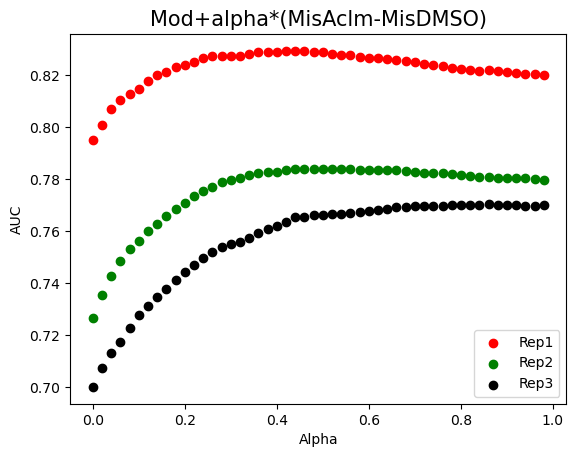

In [145]:
print("Only Mis(Aclm-DMSO)")
Prim_scores150_mis=CalculateSHAPEFromBitvector_mis(Bitvector150,DMSOBitvector,1)
Prim_scores100_mis=CalculateSHAPEFromBitvector_mis(Bitvector100,DMSOBitvector,1)
Prim_scores75_mis=CalculateSHAPEFromBitvector_mis(Bitvector75,DMSOBitvector,1)
Start=2
scores=Prim_scores150_mis
subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
print(General.calc_AUC_v2(mirdot_6,subscores))
scores=Prim_scores100_mis
subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
print(General.calc_AUC_v2(mirdot_6,subscores))
scores=Prim_scores75_mis
subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
print(General.calc_AUC_v2(mirdot_6,subscores))

print("Only Mod:")
Prim_scores150_mod=CalculateSHAPEFromBitvector_mod(Bitvector150)
Prim_scores100_mod=CalculateSHAPEFromBitvector_mod(Bitvector100)
Prim_scores75_mod=CalculateSHAPEFromBitvector_mod(Bitvector75)

Start=2
scores=Prim_scores150_mod
Prim_PORE_cupinescores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
print(General.calc_AUC_v2(mirdot_6,Prim_PORE_cupinescores_6))
Start=2
scores=Prim_scores100_mod
Prim_PORE_cupinescores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
print(General.calc_AUC_v2(mirdot_6,Prim_PORE_cupinescores_6))
Start=2
scores=Prim_scores75_mod
Prim_PORE_cupinescores_6=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
print(General.calc_AUC_v2(mirdot_6,Prim_PORE_cupinescores_6))


print("Mod+DeltaMis:")

alpha=list(np.arange(0,1,0.02))
aucs150=[]
aucs100=[]
aucs75=[]

for i in alpha:
    Prim_scores_mod=CalculateSHAPEFromBitvector_control(Bitvector150,DMSOBitvector,i)
    Start=2
    scores=Prim_scores_mod
    subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
    aucs150.append(General.calc_AUC_v2(mirdot_6,subscores))

for i in alpha:
    Prim_scores_mod=CalculateSHAPEFromBitvector_control(Bitvector100,DMSOBitvector,i)
    Start=2
    scores=Prim_scores_mod
    subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
    aucs100.append(General.calc_AUC_v2(mirdot_6,subscores))

for i in alpha:
    Prim_scores_mod=CalculateSHAPEFromBitvector_control(Bitvector75,DMSOBitvector,i)
    Start=2
    scores=Prim_scores_mod
    subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
    aucs75.append(General.calc_AUC_v2(mirdot_6,subscores))

plt.scatter(alpha, aucs150,c = 'r', label='Rep1')
plt.scatter(alpha, aucs100,c = 'g', label='Rep2')
plt.scatter(alpha, aucs75,c = 'k', label='Rep3')
plt.title('Mod+alpha*(MisAclm-MisDMSO)',fontsize=15)
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('AUC')
plt.show()



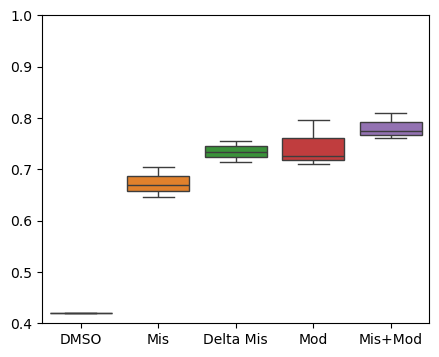

0.04085798278741251 0.00839115829282277


In [141]:
aucdata = [[0.42,0.704,0.714,0.796,0.810],[0.42,0.669,0.755,0.726,0.775],[0.42,0.646,0.734,0.710,0.760]]
aucdf = pd.DataFrame(aucdata,columns=['DMSO','Mis','Delta Mis','Mod','Mis+Mod'])

plt.figure(figsize=(5,4))
sns.boxplot(data=aucdf)
plt.ylim(0.4,1)
#plt.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/AUCs-4种方法比较.pdf")
#plt.close()
plt.show()
R1,P1=stats.ttest_ind(aucdf['Mis'],aucdf['Delta Mis'])
R2,P2=stats.ttest_ind(aucdf['Mis+Mod'],aucdf['Mis'])
print(P1,P2)

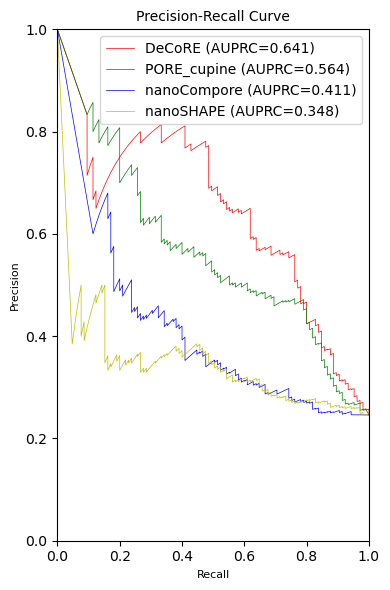

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,precision_recall_curve, auc,average_precision_score
from sklearn.datasets import make_classification

def calc_AUPCR(dot, shape_list):
    """
    dot                 -- Dotbracket structure
    shape_list          -- A list of SHAPE scores
    
    Calculate the AUPRC between structure and shape
    
    Return [point1, point2, point3,...]
    """
    
    assert len(dot) == len(shape_list)
    assert len(dot) > 20
    
    dot_array = np.array(list(dot))
    shape_array = np.array(shape_list, dtype=str)
    
    dot_array = dot_array[shape_array!='NULL']
    shape_array = shape_array[shape_array!='NULL']
    shape_array = shape_array.astype(float)
    
    unpaired = (dot_array=='.')
    
    precision, recall, thresholds = precision_recall_curve(unpaired, shape_array)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_f1_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_f1_idx]
    best_threshold = thresholds[best_f1_idx]
    best_precision = precision[best_f1_idx]
    best_recall = recall[best_f1_idx]
    y_pred_optimized = (shape_array >= best_threshold/10).astype(int)
    
    #precision, recall, thresholds = precision_recall_curve(unpaired, y_pred_optimized)
    precision, recall, thresholds = precision_recall_curve(unpaired, shape_array)

    auprc = auc(recall, precision)
    
    return recall,precision,auprc,best_f1,best_threshold

recall,precision,auprc,best_f1,best_t=calc_AUPCR(mirdot_6,DecoRe_scores_6)
recall_C,precision_C,auprc_C,best_f1_C,best_t_C=calc_AUPCR(mirdot_6,np.nan_to_num(nanoComporescores_6, nan=0))
recall_P,precision_P,auprc_P,best_f1_P,best_t_P=calc_AUPCR(mirdot_6,Prim_PORE_cupinescores_6)
recall_S,precision_S,auprc_S,best_f1_S,best_t_S=calc_AUPCR(mirdot_6,nanoSHAPEscores_6)


# 绘制PR曲线
plt.figure(figsize=(4, 6))
plt.plot(recall, precision, 'r-', linewidth=0.5, label=f'DeCoRE (AUPRC={auprc:.3f})')
plt.plot(recall_P, precision_P, 'g-', linewidth=0.5, label=f'PORE_cupine (AUPRC={auprc_P:.3f})')
plt.plot(recall_C, precision_C, 'b-', linewidth=0.5, label=f'nanoCompore (AUPRC={auprc_C:.3f})')
plt.plot(recall_S, precision_S, 'y-', linewidth=0.5, label=f'nanoSHAPE (AUPRC={auprc_S:.3f})')

#plt.plot([0, 1], [0.5, 0.5], 'r--', label='Random Classifier (AUPRC = 0.5)')
plt.xlabel('Recall', fontsize=8)
plt.ylabel('Precision', fontsize=8)
plt.title('Precision-Recall Curve', fontsize=10)
plt.legend(loc='best')
#plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
#plt.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/4Methods_AUPRC4.3.pdf") 
#plt.close()
plt.show()


Best threshold (F1): 0.280
Precision: 0.565
Recall: 0.743
F1: 0.642
Best threshold (F1): 0.170
Precision: 0.333
Recall: 0.571
F1: 0.421
Best threshold (F1): 0.120
Precision: 0.471
Recall: 0.762
F1: 0.582
Best threshold (F1): 0.600
Precision: 0.315
Recall: 0.648
F1: 0.424


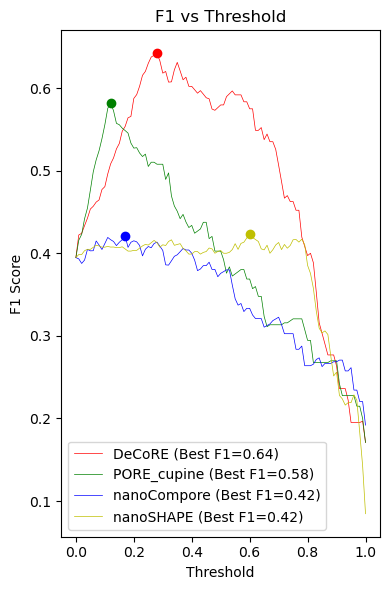

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ======================
# 输入数据（需要替换）
# ======================
# y_true: 真实标签（1 = unpaired, 0 = paired）
# scores: 预测的 reactivity score（0~1）

# 示例（请替换成你的真实数据）
# y_true = [...]
# scores = [...]


def calc_AUPCR_threshold(dot, shape_list):
    y_true = [1 if base == '.' else 0 for base in dot]
    scores = shape_list
    thresholds = np.linspace(0, 1, 101)

    precision_list = []
    recall_list = []
    f1_list = []
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    # ======================
    # 找最优 threshold（基于 F1）
    # ======================
    best_idx = np.argmax(f1_list)
    best_threshold = thresholds[best_idx]
    
    print(f"Best threshold (F1): {best_threshold:.3f}")
    print(f"Precision: {precision_list[best_idx]:.3f}")
    print(f"Recall: {recall_list[best_idx]:.3f}")
    print(f"F1: {f1_list[best_idx]:.3f}")

    return thresholds,best_threshold,f1_list,f1_list[best_idx]

# ======================
# 绘图
# ======================

thresholds,  best_threshold,  f1_list,  best_f1=  calc_AUPCR_threshold(mirdot_6,DecoRe_scores_6)
thresholds_C,best_threshold_C,f1_list_C,best_f1_C=calc_AUPCR_threshold(mirdot_6,np.nan_to_num(nanoComporescores_6, nan=0))
thresholds_P,best_threshold_P,f1_list_P,best_f1_P=calc_AUPCR_threshold(mirdot_6,Prim_PORE_cupinescores_6)
thresholds_S,best_threshold_S,f1_list_S,best_f1_S=calc_AUPCR_threshold(mirdot_6,nanoSHAPEscores_6)

plt.figure(figsize=(4, 6))

#plt.plot(thresholds, precision_list, label="Precision")
#plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds,   f1_list,   'r-', linewidth=0.5, label=f"DeCoRE (Best F1={best_f1:.2f})")
plt.plot(thresholds_P, f1_list_P, 'g-', linewidth=0.5, label=f"PORE_cupine (Best F1={best_f1_P:.2f})")
plt.plot(thresholds_C, f1_list_C, 'b-', linewidth=0.5, label=f"nanoCompore (Best F1={best_f1_C:.2f})")
plt.plot(thresholds_S, f1_list_S, 'y-', linewidth=0.5, label=f"nanoSHAPE (Best F1={best_f1_S:.2f})")

# 标记最佳点
#plt.axvline(best_threshold, linestyle='--')
plt.scatter(best_threshold, best_f1,c='r')
plt.scatter(best_threshold_P, best_f1_P, c='g')
plt.scatter(best_threshold_C, best_f1_C, c='b')
plt.scatter(best_threshold_S, best_f1_S, c='y')

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.legend()
#plt.grid(True)

plt.tight_layout()
#plt.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/4Methods_AUPRC—threshold 4.3.pdf") 
#plt.close()
plt.show()

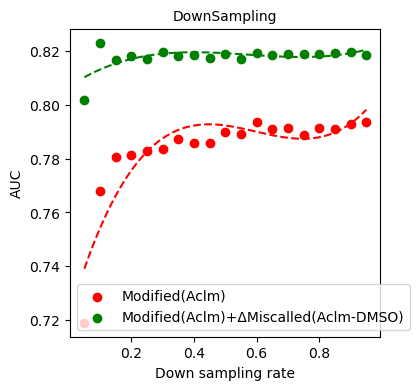

In [140]:
#down sampling
def CalculateSHAPEFromBitvector_mod(Modvect):
    Percentlist=[]
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    rates=NAI_one/(NAI_one+NAI_zero)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def CalculateSHAPEFromBitvector_mis(Modvect,Unmodvect,alpha=1):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero)+np.multiply(delta,alpha)
    shapescore=Normal_SHAPE(rates)
    return shapescore

alpha=list(np.arange(0.05,1,0.05))
aucs_mod=[]
aucs_withmis=[]

for i in alpha:
    NAIsample=Bitvector150.sample(frac=i, random_state=42) 
    DMSOsample=DMSOBitvector.sample(frac=i, random_state=42) 
    Prim_scores_mod=CalculateSHAPEFromBitvector_mod(NAIsample)
    Start=2
    scores=Prim_scores_mod
    subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
    aucs_mod.append(General.calc_AUC_v2(mirdot_6,subscores))

for i in alpha:
    NAIsample=Bitvector150.sample(frac=i, random_state=42) 
    DMSOsample=DMSOBitvector.sample(frac=i, random_state=42) 
    Prim_scores_mod=CalculateSHAPEFromBitvector_mis(NAIsample,DMSOsample,1)
    Start=2
    scores=Prim_scores_mod
    subscores=scores[110-Start:180-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
    aucs_withmis.append(General.calc_AUC_v2(mirdot_6,subscores))

coefficients_mod = np.polyfit(alpha, aucs_mod, 3)
coefficients_mis = np.polyfit(alpha, aucs_withmis, 3)

p_mod = np.poly1d(coefficients_mod)
p_mis = np.poly1d(coefficients_mis)

x_fit = np.linspace(min(alpha), max(alpha), 100)
y_fit_mod = p_mod(x_fit)
y_fit_mis = p_mis(x_fit)

fig = plt.figure(1, figsize=(4, 4))
plt.scatter(alpha, aucs_mod,c = 'r', label='Modified(Aclm)')
plt.plot(x_fit, y_fit_mod,c = 'r',linestyle='--') #拟合线

plt.scatter(alpha, aucs_withmis,c = 'g', label='Modified(Aclm)+ΔMiscalled(Aclm-DMSO)')
plt.plot(x_fit, y_fit_mis,c = 'g',linestyle='--') #拟合线

plt.title('DownSampling',fontsize=10)
plt.legend()
plt.xlabel('Down sampling rate')
plt.ylabel('AUC')
#plt.savefig("/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/DownSampling3.24.pdf") 
#plt.close()
plt.show()

In [ ]:
#Test UAD models and features
def SVM(testevent,trainevent,poslist,GA=0.01,NU=0.01,cols=[4,5,6]):
    Staticfile={}
    TestwithPred=pd.DataFrame()
    for b in poslist: #对每个坐标，提取出所有reads在该位点的值，判断两个群之间的差异
        Train=trainevent[trainevent['position']==b]
        Test=testevent[testevent['position']==b]
        if Test.shape[0] >10 and Train.shape[0] >10:
            #training of unmodified
            clf = OneClassSVM(gamma=GA,kernel='rbf',nu=NU).fit(np.array(Train.iloc[:,cols]))
            #Predicting of modified
            Testout=clf.predict(np.array(Test.iloc[:,cols]))
            Test['Predict']=Testout
            TestwithPred=pd.concat([TestwithPred,Test],axis=0)
            #统计-1和1的个数
            d = Counter(Testout)
            d_s = sorted(d.items(),key=lambda x:x[1],reverse=True)
            #将结果输出到Staticfile字典
            if len(d_s)==2:
                Staticfile[b]=[d_s[1][1],Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
            if len(d_s)==1:
                Staticfile[b]=[0,Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
        else:
            Staticfile[b]=[0,'NULL',Test.shape[0],Train.shape[0]]
    return Staticfile,TestwithPred

def SGDSVM(testevent,trainevent,poslist,GA=0.005,NU=0.02,cols=[4,5,6]):
    from sklearn.kernel_approximation import Nystroem
    from sklearn.pipeline import make_pipeline
    Staticfile={}
    TestwithPred=pd.DataFrame()
    for b in poslist: #对每个坐标，提取出所有reads在该位点的值，判断两个群之间的差异
        Train=trainevent[trainevent['position']==b]
        Test=testevent[testevent['position']==b]
        if Test.shape[0] >10 and Train.shape[0] >10:
            #training of unmodified
            sgd = make_pipeline(Nystroem(gamma=GA,n_components=2),SGDOneClassSVM(shuffle=True,fit_intercept=True,nu=NU)).fit(np.array(Train.iloc[:,cols]))
            #Predicting of modified
            Testout=sgd.predict(np.array(Test.iloc[:,cols]))
            Test['Predict']=Testout
            TestwithPred=pd.concat([TestwithPred,Test],axis=0)
            #统计-1和1的个数
            d = Counter(Testout)
            d_s = sorted(d.items(),key=lambda x:x[1],reverse=True)
            #将结果输出到Staticfile字典
            if len(d_s)==2:
                Staticfile[b]=[d_s[1][1],Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
            if len(d_s)==1:
                Staticfile[b]=[0,Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
        else:
            Staticfile[b]=[0,'NULL',Test.shape[0],Train.shape[0]]
    return Staticfile,TestwithPred

def IOF(testevent,trainevent,poslist,CTN=0.05,EST=100,cols=[4,5,6]):
    Staticfile={}
    TestwithPred=pd.DataFrame()
    for b in poslist: #对每个坐标，提取出所有reads在该位点的值，判断两个群之间的差异
        Train=trainevent[trainevent['position']==b]
        Test=testevent[testevent['position']==b]
        if Test.shape[0] >10 and Train.shape[0] >10:
            #training of unmodified
            iof = IsolationForest(contamination=CTN,n_estimators=EST).fit(np.array(Train.iloc[:,cols]))
            #Predicting of modified
            Testout=iof.predict(np.array(Test.iloc[:,cols]))
            Test['Predict']=Testout
            TestwithPred=pd.concat([TestwithPred,Test],axis=0)
            #统计-1和1的个数
            d = Counter(Testout)
            d_s = sorted(d.items(),key=lambda x:x[1],reverse=True)
            #将结果输出到Staticfile字典
            if len(d_s)==2:
                Staticfile[b]=[d_s[1][1],Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
            if len(d_s)==1:
                Staticfile[b]=[0,Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
        else:
            Staticfile[b]=[0,'NULL',Test.shape[0],Train.shape[0]]
    return Staticfile,TestwithPred

def LOF(testevent,trainevent,poslist,CTN=0.05,NEB=20,cols=[4,5,6]):
    Staticfile={}
    TestwithPred=pd.DataFrame()
    for b in poslist: #对每个坐标，提取出所有reads在该位点的值，判断两个群之间的差异
        Train=trainevent[trainevent['position']==b]
        Test=testevent[testevent['position']==b]
        if Test.shape[0] >10 and Train.shape[0] >10:
            #training of unmodified
            lof = LocalOutlierFactor(contamination=CTN,n_neighbors=NEB,novelty=True).fit(np.array(Train.iloc[:,cols]))
            #Predicting of modified
            Testout=lof.predict(np.array(Test.iloc[:,cols]))
            Test['Predict']=Testout
            TestwithPred=pd.concat([TestwithPred,Test],axis=0)
            #统计-1和1的个数
            d = Counter(Testout)
            d_s = sorted(d.items(),key=lambda x:x[1],reverse=True)
            #将结果输出到Staticfile字典
            if len(d_s)==2:
                Staticfile[b]=[d_s[1][1],Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
            if len(d_s)==1:
                Staticfile[b]=[0,Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
        else:
            Staticfile[b]=[0,'NULL',Test.shape[0],Train.shape[0]]
    return Staticfile,TestwithPred

def RCV(testevent,trainevent,poslist,CTN=0.05,SFC=0.6,cols=[4,5,6]):
    Staticfile={}
    TestwithPred=pd.DataFrame()
    for b in poslist: #对每个坐标，提取出所有reads在该位点的值，判断两个群之间的差异
        Train=trainevent[trainevent['position']==b]
        Test=testevent[testevent['position']==b]
        if Test.shape[0] >10 and Train.shape[0] >10:
            #training of unmodified
            lof = EllipticEnvelope(contamination=CTN,support_fraction=SFC).fit(np.array(Train.iloc[:,cols]))
            #Predicting of modified
            Testout=lof.predict(np.array(Test.iloc[:,cols]))
            Test['Predict']=Testout
            TestwithPred=pd.concat([TestwithPred,Test],axis=0)
            #统计-1和1的个数
            d = Counter(Testout)
            d_s = sorted(d.items(),key=lambda x:x[1],reverse=True)
            #将结果输出到Staticfile字典
            if len(d_s)==2:
                Staticfile[b]=[d_s[1][1],Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
            if len(d_s)==1:
                Staticfile[b]=[0,Train['reference_kmer'].tolist()[1][0:1],Test.shape[0],Train.shape[0]]
        else:
            Staticfile[b]=[0,'NULL',Test.shape[0],Train.shape[0]]
    return Staticfile,TestwithPred

methods=['SVM','SGDSVM','IOF','LOF','RCV']
def UADmodels(testevent,trainevent,posList,method='SVM',cols=[4,6],spotion=285):
    if method=='SVM':
        Finalfile,Predct=SVM(testevent,trainevent,posList,GA=0.005,NU=0.005,cols=cols)
    if method=='SGDSVM':
        Finalfile,Predct=SGDSVM(testevent,trainevent,posList,GA=0.002,NU=0.01,cols=cols)
    if method=='IOF':
        Finalfile,Predct=IOF(testevent,trainevent,posList,CTN=0.03,EST=100,cols=cols)
    if method=='LOF':
        Finalfile,Predct=LOF(testevent,trainevent,posList,CTN=0.03,NEB=100,cols=cols)
    if method=='RCV':
        Finalfile,Predct=RCV(trainevent,testevent,posList,CTN=0.03,SFC=0.9,cols=cols)
    return Finalfile,Predct[Predct['position']==spotion]

for i in methods:
    Finalfile, Predct285=UADmodels(mir_NAI1event2,mir_DMSOevent,posList_mir,i,[4,6],285)
    #Finalfile,Predct=SVM(mir_NAI1event2,mir_DMSOevent,posList_mir,GA=0.005,NU=0.01,cols=[4,5,6])
    #FinalfileRCV,Predct=RCV(mir_NAI1event2,mir_DMSOevent,posList,CTN=0.03,SFC=0.9,cols=[4,6])
    Modtable=pd.DataFrame.from_dict(Finalfile, orient='index',columns=['Modifired','Kmer','TestNO.','TrainNO.'])
    ratio=[np.nan if Modtable['Kmer'][j]=='NULL' else Modtable['Modifired'][j]/Modtable['TestNO.'][j] for j in range(1,Modtable.shape[0]+1)]
    scores=Normal_SHAPE(ratio)
    Start=2
    scores_7=scores[110-Start:180-Start]+scores[193-Start:220-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
    AUC=General.calc_AUC_v2(mirdot_7,scores_7)    
    ROC=General.calc_shape_structure_ROC(mirdot_7, scores_7, start=0.0, step=0.01, stop=1.0)
    plotROC(ROC,AUC,i,f"/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/{i}_ROC.pdf")
    plotOutlier(Predct285,285,[1,-1],f"/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/{i}_Outlier.pdf")
    print(f'The {i} model was finished the analysis!')

clos=[[4],[4,5],[4,6],[4,5,6]]
n=0
for c in clos:
    n+=1
    Finalfile, Predct=SVM(mir_NAI1event2,mir_DMSOevent,posList_mir,GA=0.005,NU=0.01,cols=c)

    Modtable=pd.DataFrame.from_dict(Finalfile, orient='index',columns=['Modifired','Kmer','TestNO.','TrainNO.'])
    ratio=[np.nan if Modtable['Kmer'][j]=='NULL' else Modtable['Modifired'][j]/Modtable['TestNO.'][j] for j in range(1,Modtable.shape[0]+1)]
    scores=Normal_SHAPE(ratio)
    Start=2
    scores_7=scores[110-Start:180-Start]+scores[193-Start:220-Start]+scores[249-Start:320-Start]+scores[392-Start:468-Start]+scores[572-Start:624-Start]+scores[684-Start:783-Start]+scores[821-Start:880-Start]
    AUC=General.calc_AUC_v2(mirdot_7,scores_7)    
    ROC=General.calc_shape_structure_ROC(mirdot_7, scores_7, start=0.0, step=0.01, stop=1.0)
    plotROC(ROC,AUC,,f"/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/{c}.SVM.pdf")
    #plotOutlier(Predct285,285,[1,-1],f"/data1/huangyong/Project/Nanopore/nanoSHAPE/Mod150/{i}_Outlier.pdf")
    print(f'The {i} model was finished the analysis!')
